In [1]:
import sys
import os
import logging

init_dir = "C:/Users/MRudolph/Documents/GitHub/CFPy/vlab"
os.chdir(init_dir)
sys.path.insert(0, init_dir)

# Import the pyKasso and numpy packages
import pykasso as pk

import glob
import shutil

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import CFPy as cfpy
import flopy as flopy
import flopy.utils.binaryfile as bf
import numpy as np
import pandas as pd
import pastas as ps
from scipy.stats import qmc

# import fractionation recharge model
from recharge import FlexModelFrac

# Define Helper Functions

In [2]:
def clean_results(path):
    """
    Remove all run-dictionaries
    
    Keyword Arguments
    -
    
    Return
    -
    """    
    run_dirs = glob.glob(os.path.join(path, "run_*"))    
    for rd in run_dirs:
        shutil.rmtree(rd)

# Set up Model

In [3]:
# load prec and evap data
prec = pd.read_csv(
    os.path.join(init_dir, "prec.csv"),
    parse_dates=True,
    index_col=[0],
    sep=";",
    usecols=[0, 2],
    dayfirst=True
).resample("D").sum()

evap = pd.read_csv(
    os.path.join(init_dir, "evap.csv"),
    parse_dates=True,
    index_col=[0],
    sep=";",
    dayfirst=True
)

In [ ]:
def run_vlab(proj_name, prec, evap, rch_params, sks_seed, hk, k_exchange,
             cad, diameter, rheight, stop_after_pyKasso, show_figures):
    """
    Parameters
    ----------
    proj_name : str
        project name
    prec : numpy.ndarray
        daily precipitation time series (prec. given in mm/d). the length
        of prec determines the number of stress periods in the modflow
        model (1 period for each day).
    evap : numpy.ndarray
        daily evapo(transpi)ration time series (evap. given in mm/d).
    rch_params : list-like
        pastas recharge model parameters with shape (7,). parameters have
        to be in the order [srmax, lp, ks, gamma, simax, kv, omega].
    sks_seed : int
        conduit network geneartion random seed.
    hk : float
        hydraulic conductivity in m/s.
    stop_after_pyKasso : bool
        trigger to stop the vlab after pyKasso. intended so that the
        network generation process can be tuned independently of modflow.
    show_figures : bool
        whether to show the figures or not.
    """

    ###
    ###
    ###
    ### recharge
    ###
    ###
    ###

    # set up recharge model
    rch_ml = FlexModelFrac()

    # define number of time series repeats for warmup
    n_tiles = 5

    # create model time series
    prec_ml = np.tile(prec.values.ravel(), n_tiles) # incl warmup
    evap_ml = np.tile(evap.values.ravel(), n_tiles) # incl warmup

    # simulate
    # consider default params: [250., 25., 1000., 2., 1., 5., .2]
    rch_slow, rch_quick = rch_ml.simulate(
        prec=prec_ml,
        evap=evap_ml,
        p=np.array(rch_params)
    )

    # add slow and quick recharge components
    recharge_ts = rch_slow + rch_quick
    
    # truncate recharge ts
    recharge_ts = recharge_ts[len(prec) * (n_tiles - 1):]
    # recharge_ts = recharge_ts[:20]

    ###
    ###
    ###
    ### model domain settings
    ###
    ###
    ###

    # number of rows, columns, widths etc.
    n_rows = 50
    n_cols = 100
    n_lays = 1
    delr = 25.0
    delc = 25.0
    lay_elevs = [50.,0.]

    # defined head at spring node, m
    chb_spring = 10.0

    ###
    ###
    ###
    ### pyKasso
    ###
    ###
    ###

    # create a pyKasso application
    app = pk.pykasso()

    # compute domain thickness for pyKasso
    # we assume here that we have just one MODFLOW layer
    thickness_pk = lay_elevs[0] - lay_elevs[-1]
    nz = 10
    dz = thickness_pk / nz

    # declare the grid parameters
    grid_parameters = {
        'x0': 0, 'y0': 0, 'z0': 0,
        'nx': n_cols, 'ny': n_rows, 'nz': nz, # ncol, nrow, xxx
        'dx': delr, 'dy': delc, 'dz': thickness_pk / nz,
    }

    # declare the project parameters
    app.new_project(name=proj_name + "_pyKasso",
                    grid_parameters=grid_parameters)
    
    # declare some options for the visualization
    app.visualizer.notebook = True
    extent = app.project.grid.extent
    imshow_options = {'extent': extent}

    # define bedrock and water table
    bedrock = np.zeros((grid_parameters["nx"], grid_parameters["ny"]))
    water_table = np.full((grid_parameters["nx"], grid_parameters["ny"]),
                          chb_spring)
    
    # declare the model parameters
    model_parameters = {
        'sks' : {
            'seed' : sks_seed,
            'algorithm': "Riemann3",
            'ratio': .1,
        },
        'domain' : {
            'bedrock' : bedrock,
            'water_table' : water_table
        },
        'outlets' : {
            'seed': 7,
            'number' : 1,
            'subdomain': 'domain_borders_bottom',
        },
        'inlets' : {
            'number': 5,
            'seed': 456,
            'subdomain': 'domain_surface'
            # 'number': 3,
        },
        'fractures' : {
            'generate': {
                'family_01': {
                    'density'      : 0.000007,
                    'orientation'  : [135, 160],
                    'dip'          : [90, 160],
                    'length'       : [300, 400],
                    'alpha'        : 1.5
                },
                'family_02': {
                    'density'      : 0.000007,
                    'orientation'  : [45, 80],
                    'dip'          : [90, 120],
                    'length'       : [500, 700],
                    'alpha'        : 1.5
                },
                'family_03': {
                    'density'      : 0.000004,
                    'orientation'  : [0, 60],
                    'dip'          : [90, 120],
                    'length'       : [500, 700],
                    'alpha'        : 1.5
                }
            }
        },
    }

    # run the model
    app.model.generate(model_parameters=model_parameters)

    # if show_figures:
    #     # Basic settings for pv_show() 
    #     settings = {
    #         'mask_values': [0], # To mask the geology
    #         'surfaces_options' : { # To see the top bedrock and water level
    #             # 'bedrock' : {'opacity':1, 'cmap': 'copper'},
    #             'water_table' : {},
    #         },
    #         'inlets_options' : {},
    #         'outlets_options' : {},
    #         'show_scalar_bar' : False,
    #     }

    #     # To select the two last simulations
    #     last_simulations = app.project.get_last_simulations(1)

    #     # Generating the 3D plot
    #     app.visualizer.pv_show(
    #         simulations=last_simulations,
    #         features=['karst'],
    #         cpos=[1, -1, 1],
    #         settings=settings,
    #         window_size=(1000, 500),
    #         zoom=1.4,
    #     )
    
    ###
    ###
    ###
    ### postprocess pyKasso results for CFPy
    ###
    ###
    ###

    # shape (nx, ny, nz) == (ncol, nrow, nlay)
    network = np.array(app.model.maps['karst'][0])
    network = np.moveaxis(network, 1, 0)

    elevations = app.model.node_elev_arr
    elevations = np.moveaxis(elevations, 1, 0)

    outlets = app.model.maps["outlets"]
    outlets = np.moveaxis(outlets, 1, 0)

    # "project" the nodes onto the plane
    network = np.max(network, axis=-1)[::-1, :]
    # perform the same transform with elevs
    elevations = np.max(elevations, axis=-1)[::-1, :]
    # perform the same transform with outlets
    outlets = np.nanmax(outlets, axis=-1)[::-1, :]

    # validate the network from pyKasso
    validator = cfpy.preprocessing.GeneralValidator(network=network,
                                                    elevations=elevations)
    valid_network = validator.validate_network_elevations()

    # get the modflow indices for spring
    # get the first spring only
    idxs_spring_pk = np.argwhere(~np.isnan(outlets))[0]
    # reverse column and row index and add 1 to conform with modflow
    # indices here ultimately have 1-based indexing
    idxs_spring = [int(idxs_spring_pk[1] + 1), int(idxs_spring_pk[0] + 1), 1]

    # get the modflow indices for inlet
    # store the nodes in a DataFrame
    df = pd.DataFrame.from_dict(
        app.model.vectors['nodes'],
        orient='index',
        columns=['x', 'y', 'z', 'type'],
    )
    # get inlet locations
    df = df[df["type"] == "inlet"]

    # get indices
    # indices here ultimately have 1-based indexing
    idxs_inlet = []
    for i in df.iterrows():
        x = i[1]["x"]
        y = i[1]["y"]

        col, row = app.model.grid.get_indices((x, y))
        idxs_inlet.append([int(col[0]) + 1, n_rows - int(row[0]), 1])

    # expand elevations to array
    lay_elevs_array = [np.ones((n_rows, n_cols)) * lay_elevs[0],
                    np.ones((n_rows, n_cols)) * lay_elevs[1]]
    
    if show_figures:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
        # create truncated colormap
        # cmap = plt.get_cmap("terrain")
        # truncated_cmap = mcolors.LinearSegmentedColormap.from_list(
        #     "trunc_viridis",
        #     cmap(np.linspace(0.25, 0.75, 256))  # use colors from 25% to 75%
        # )
        network_plot = valid_network.copy()
        network_plot[network_plot == 0.] = np.nan
        im = ax.matshow(network_plot, cmap="cividis", vmin=2., 
                           vmax=11.)
        plt.colorbar(im, label="Elevation [m]", shrink=0.7)
        # scatter inlets and outlet
        # each inlet is (col, row, lay) with 1-based indexing
        inlets_ = np.array(idxs_inlet)
        ax.scatter(inlets_[:, 0] - 1, inlets_[:, 1] - 1, c="r", marker="v",
                   edgecolor="k", s=70)
        ax.scatter([idxs_spring[0]], [idxs_spring[1]], c="cyan", marker=">",
                   edgecolor="k", s=70, clip_on=False, zorder=1000)
        ax.set_xlabel("Col")
        ax.set_ylabel("Row")
        ax.set_xlim(-0.5, n_cols - 0.5)
    
    # potentially break here
    if stop_after_pyKasso:
        return

    ###
    ###
    ###
    ### modflow general settings
    ###
    ###
    ###

    # change active directory to model directory

    path = os.getcwd() + "/"
    path = os.path.join(os.getcwd(), proj_name + "_modflow")

    if not os.path.exists(path):
        os.makedirs(path)

    os.chdir(path)

    # set model name
    modelname = "pyKasso_example"

    path_to_exe = "C:/WRDAPP/CFPv2.exe"
    mf = flopy.modflow.Modflow(modelname, exe_name=path_to_exe)

    # temporal discretization, 1 leading steady-state period
    time_unit = 1 # seconds
    n_pers = len(recharge_ts) + 1 # one steady period at the beginning
    perlen = 86400 # 1 day
    n_stps = [1] + [1] * (n_pers - 1)
    steady = [1] + [0] * (n_pers - 1)

    # matrix starting head, m
    H_init = 75.0

    # modflow general tolerance
    mftol = 1e-4

    # modflow relaxation parameter
    mfrelax = 0.98

    # CFP general tolerance
    cfptol = 1e-5

    # CFP relaxation parameter
    cfprelax = 0.98

    # dis
    # Create dis object
    dis = flopy.modflow.ModflowDis(mf, n_lays, n_rows, n_cols, n_pers,
                                   delr, delc, top=lay_elevs[0],
                                   botm=lay_elevs[1], perlen=perlen,
                                   nstp=n_stps, steady=steady,
                                   itmuni=time_unit, lenuni=2)

    # bas6
    # integer array of dim (z,y,x), makes all cells active 
    ibound = np.ones((n_lays, n_rows, n_cols), dtype=np.int32)

    # initialize starting head array
    H_init_array = np.ones((n_lays, n_rows, n_cols), dtype=np.float32)
    # assign starting head values to all cells
    H_init_array[:,:,:] = H_init

    bas = flopy.modflow.ModflowBas(mf, ibound=ibound, strt=H_init)

    # lpf
    #unit number to save outputs to
    ipakcb = 50
    #value assigned to dry cells
    hdry = 999.
    #0=confined, >0 = unconfined/convertible
    laytyp = 1
    #method of calculating interblock tranmissivity,
    # 0=harmonic mean (default)
    layavg = 0
    #horizontal anisotropy (ratio of Ky (along cols) to Kx (along rows)
    chani = 1
    #indicates vka = Kz
    layvka = 0
    #wetting, 0=inactive, 1=active
    laywet = 0
    # vka
    vka = hk
    # specific storage
    ss = 1e-4
    # specific yield
    sy = 1e-2

    lpf = flopy.modflow.ModflowLpf(mf, laytyp=laytyp, chani=chani,
                                   layvka=layvka, laywet=laywet,
                                   ipakcb=ipakcb, hdry=hdry, hk=hk,
                                   hani=chani, vka=vka, wetdry=laywet,
                                   ss=ss, sy=sy)

    # oc
    # create dictionary
    per_dict = {}
    for i in range(n_pers):
        per_dict[(i, 0)] = ["save head", "print budget"]

    # create output control file using dictionary
    oc = flopy.modflow.ModflowOc(mf, stress_period_data=per_dict)

    # pcg
    #max number of outer iterations
    mxiter = 5000
    #number of inner iterations
    iter1 = 5000
    #flag for matrix conditioning method, 1=modified incomplete cholesky
    npcond = 1
    #flag for active cell surrounded by dry cells. 0=converts to dry,
    # not0=converts only if hcof=0
    ihcofadd = 9999
    #relaxation parameter with npcond=1
    relax = mfrelax
    #estimate of upper bound
    nbpol = 2
    #printout interval
    iprpcg = 5
    #print flag, 5=?
    mutpcg = 0
    #damping factor
    damppcg = 0.99

    pcg = flopy.modflow.ModflowPcg(mf, mxiter=mxiter, iter1=iter1,
                                   npcond=npcond, hclose=mftol,
                                   rclose=mftol, relax=relax, nbpol=nbpol,
                                   iprpcg=iprpcg, mutpcg=mutpcg,
                                   damp=damppcg, ihcofadd=ihcofadd)

    # rch
    # flag, 1=rech only applied to top layer
    nrchop = 1
    # if non-zero, cell budget data will be saved
    ipakcb = 50

    # # dictionary of recharge fluxes for each stress period
    rech = {}

    rch_mean = np.mean(recharge_ts) / 86400 / 1000
    rech[0] = rch_mean

    for i in range(n_pers - 1):
        rch_ = recharge_ts[i] / 86400 / 1000 # mm/d --> mm/s --> m/s
        rech[i + 1] = rch_

    rch = flopy.modflow.mfrch.ModflowRch(mf, nrchop=nrchop, ipakcb=ipakcb,
                                         rech=rech)
    
    ###
    ###
    ###
    ### cfp settings
    ###
    ###
    ###

    # pipe tortuosity
    tortuosity = 1.

    # lower critical reynolds number
    lcritrey = 500

    # higher critical reynolds number
    hcritrey = 5000

    # clean up
    clean_results(path)
    os.chdir(path)

    mf.write_input()

    # export the network that has been created before
    validator.export_network()

    # generate nbr file
    validator.generate_nbr(
        path = path,
        nrows = n_rows,
        ncols = n_cols,
        nlays = n_lays,
        nplanes = 1,
        layer_elevations = lay_elevs_array
    )

    # create nbr object
    nbr = cfpy.nbr()

    # read model layer/node and conduit layer/node elevations

    # bot_elev has shape (n_layers, n_rows, n_cols)
    # cond_elev has shape (n_conduit_layers, n_rows, n_cols)
    bot_elev, cond_elev = nbr.nbr_read()

    # create nbr data
    nbr_data = nbr.nbr(bot_elev, cond_elev)

    # diameter
    p_diameter = np.ones(len(nbr_data[5])) * diameter
    p_diameter = p_diameter.tolist()

    # tortuosity
    p_tortuosity = np.ones(len(nbr_data[5])) * tortuosity
    p_tortuosity = p_tortuosity.tolist()

    # roughness height
    p_rheight = np.ones(len(nbr_data[5])) * rheight
    p_rheight = p_rheight.tolist()

    # lower critical reynolds number
    p_lcritrey = np.ones(len(nbr_data[5])) * lcritrey
    p_lcritrey = p_lcritrey.tolist()

    # higher critical reynolds number
    p_hcritrey = np.ones(len(nbr_data[5])) * hcritrey
    p_hcritrey = p_hcritrey.tolist()

    # summarize all data in a 2D-array
    pipe_data = [nbr_data[5], p_diameter, p_tortuosity, p_rheight,
                 p_lcritrey, p_hcritrey]

    # node heads
    # parametrization for all n nodes
    # if head > 0: fixed head
    # if head == -1: calculated head
    n_head = np.ones((len(nbr_data[0]))) * -1
    n_head = n_head.tolist()

    # search if the spring exists in the nodes
    if idxs_spring in nbr_data[2]:
        # get the position of spring node inside nbr_data
        pos = nbr_data[2].index(idxs_spring)
        # assign the head to spring node
        n_head[pos] = chb_spring
    else:
        raise Exception("Cannot find indices of spring in the indices of nodes!")

    node_data = [nbr_data[0], n_head]

    # k_ex data
    kex_data = [nbr_data[0],
                np.ones(len(nbr_data[0])) * k_exchange]

    # cads data
    cads_data = np.ones((len(nbr_data[0]))) * cad
    cads_data = cads_data.tolist()

    # create cfp object
    cfp = cfpy.cfp(mode = 1,
                    nnodes = len(nbr_data[0]), 
                    npipes = len(nbr_data[5]), 
                    nlay = n_lays, 
                    nbr_data = nbr_data, 
                    geoheight = cond_elev, 
                    sa_exchange = 0, 
                    epsilon = cfptol,
                    niter = 2000, 
                    relax = cfprelax, 
                    p_nr = 0, 
                    cond_data = pipe_data, 
                    n_head = node_data, 
                    k_exchange = kex_data, 
                    ncl = 0, 
                    cl = 0, 
                    ltemp = 10,
                    condl_data = 0,
                    cads = cads_data)

    # create list of strings
    cfp = cfp.cfp()

    # coc
    coc = cfpy.coc(nnodes = len(nbr_data[0]),
                    node_numbers = nbr_data[0],
                    n_nts = 1,
                    npipes = len(nbr_data[5]), 
                    pipe_numbers = nbr_data[5],
                    t_nts = 1)

    coc = coc.coc()

    # crch
    # p_crch is list of length (n_nodes) specifying the direct recharge
    # fraction for each node
    # initially set p_crch to 0 for all nodes (no direct recharge)
    p_crch = np.zeros((len(nbr_data[0]))).tolist()

    for idx in idxs_inlet:
        # search if the spring exists in the nodes
        if idx in nbr_data[2]:
            # get the position of inlet node inside nbr_data
            pos = nbr_data[2].index(idx)
            # assign the head to spring node
            p_crch[pos] = 1.
        else:
            raise Exception("Cannot find indices of inlet in the indices of nodes!")

    crch = cfpy.crch(iflag_crch = 1, 
                        nper = n_pers, 
                        node_numbers = nbr_data[0], 
                        p_crch = p_crch)

    # create list of strings
    crch = crch.crch()

    """ Write Input """
    input_files = cfpy.write_input(modelname = modelname,
                                    data_strings = [coc, crch, cfp],
                                    file_extensions = ['coc', 'crch', 'cfp'])

    # write CFP input files
    input_files.write_input()

    # update nam file
    nam = cfpy.update_nam(modelname = modelname,
                            mode = 1,
                            cfp_unit_num = 52,
                            crch_unit_num = 53,
                            coc_unit_num = 54)

    # update existing .nam file
    nam.update_nam()

    # run model
    success, buff = mf.run_model(silent=True)

    # post-process model
    if show_figures:
        # head in model comain
        hds_file = os.path.join(path, f"{modelname}.hds")
        hds = bf.HeadFile(hds_file)
        head = hds.get_alldata()

        fig, ax = plt.subplots(figsize=(10, 5))

        im = ax.matshow(head[0, 0, :, :], zorder=1)
        plt.colorbar(im, label="Head [m]", shrink=0.7)
        ax.contour(
            head[0, 0, :, :],
            cmap="binary",
            linewidths=1.,
            alpha=1.,
            levels=10,
            zorder=2
        )
        # plot karst network
        network_plot = network_plot.copy()
        network_plot[network_plot >= 0.] = 1.
        ax.matshow(network_plot, cmap="hot", zorder=3)
        # ax.contour(
        #     head[0, 0, :, :],
        #     cmap="binary",
        #     linewidths=1.,
        #     alpha=1.,
        #     levels=20,
        # )
        # scatter inlets and outlet
        # each inlet is (col, row, lay) with 1-based indexing
        inlets_ = np.array(idxs_inlet)
        ax.scatter(inlets_[:, 0] - 1, inlets_[:, 1] - 1, c="r", marker="v",
                   edgecolor="k", s=70, zorder=4)
        ax.scatter([idxs_spring[0]], [idxs_spring[1]], c="cyan", marker=">",
                   edgecolor="k", s=70, clip_on=False, zorder=1000)
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_xlim(-0.5, n_cols - 0.5)
    
    # try closing a potentially open head file
    try:
        hds_file.close()
    except:
        pass

    # read spring discharge and create time series for output
    # get spring index, adding 1 to convert from 0-based to 1-based index
    node_data_arr = np.array(nbr_data[2])
    idx = np.where((node_data_arr == idxs_spring).all(axis=1))[0] + 1

    # make string for file name
    str_ = str(idx[0]).zfill(8)

    # get node flows
    flows = pd.read_fwf(
        os.path.join(path, "NODE" + str_ + ".OUT")
    )

    Q_out = flows["QMAT"] + flows["QCADS"] + flows["QTUB1"] + flows["QTUB2"] \
        + flows["QTUB3"] + flows["QTUB4"] + flows["QTUB5"] + flows["QTUB6"]
    
    return success, Q_out

In [ ]:
# base settings
sks_seed = 12345
rch_params = [250., .25, 1000., 2., 1., 5., .2]
hk = 1e-4
k_exchange = 1e-4
cad = .01
diameter = .5
rheight = 0.02

# alternative settings
sks_seed_list = [1234, 234, 345]
rch_params_list = np.random.uniform(
    low=[100., .1, 100., 1., .5, .1, .1],
    high=[500., .8, 1000., 5., 10., 10., .9],
    size=(3, 7)
)
hk_list = [1e-5, 5e-5, 1e-4]
k_exchange_list = [1e-5, 5e-5, 1e-4]
cad_list = [.01, .1, .5]
diameter_list = [.1, .5, 1.]

# create parameter vector
# [
# srmax, lp, ks, gamma, simax, kv, omega,
# hk,
# k_exchange,
# cad,
# diameter
# ]
# we separately sample from the four sks seeds that give us sensible networks
# [12345, 1234, 234, 345]

n_samples = 500

sampler = qmc.LatinHypercube(d=11, rng=1)
sample = sampler.random(n=n_samples)

low = [
        100., .1, 100., 1., .5, .1, .1, 1e-5, 1e-5, 0.01, 0.1
    ]
high = [
    500., .8, 1000., 5., 10., 10., .9, 1e-4, 1e-4, .5, 1.
]

param_samples = qmc.scale(sample, low, high)

# parameter_set = np.random.uniform(
#     low = [
#         100., .1, 100., 1., .5, .1, .1, 1e-5, 1e-5, 0.01, 0.1
#     ],
#     high = [
#         500., .8, 1000., 5., 10., 10., .9, 1e-4, 1e-4, .5, 1.
#     ],
#     size = (n_samples, 11)
# )

seed_list = np.array([12345, 1234, 234, 345])
seeds = np.random.choice(seed_list, n_samples)

param_samples = np.column_stack((seeds, param_samples))


Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.17 s
True


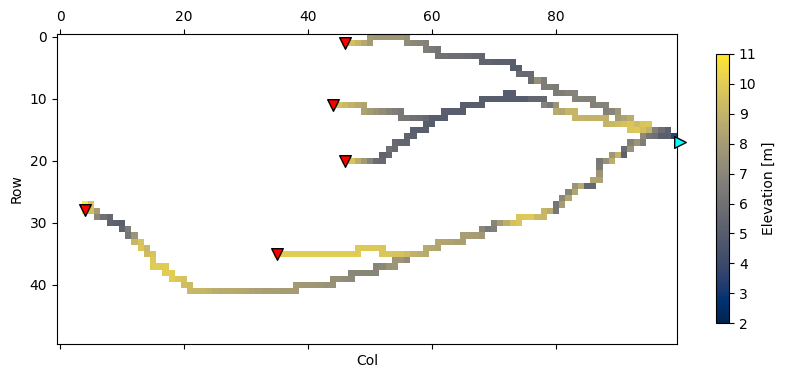

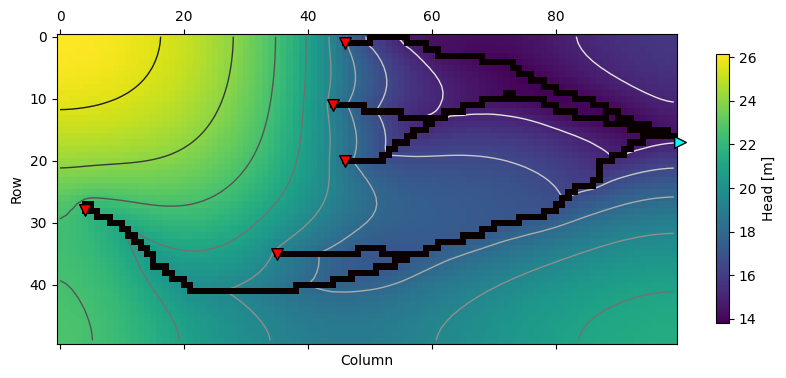

In [6]:
success, Q_out_reference = run_vlab(
    proj_name="test",
    prec=prec,
    evap=evap,
    rch_params=[250., .25, 1000., 2., 1., 5., .2],
    sks_seed=sks_seed,
    hk=hk,
    k_exchange=k_exchange,
    cad=cad,
    diameter=diameter,
    rheight=rheight,
    stop_after_pyKasso=False,
    show_figures=True
)
print(success)

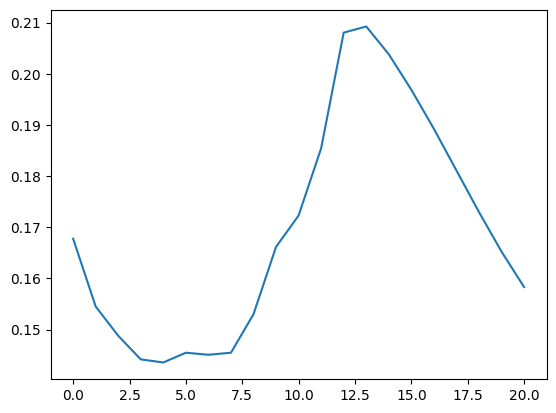

In [7]:
plt.plot(Q_out_reference)

In [8]:
output_dicts_success = []
output_dicts_failure = []

counter = 0

for i in range(n_samples):
    sks_seed = int(param_samples[i, 0])
    rch_params = param_samples[i, 1:8]
    hk = param_samples[i, 8]
    k_exchange = param_samples[i, 9]
    cads = param_samples[i, 10]
    diameter = param_samples[i, 11]

    # ensure we are in the right directory
    os.chdir(init_dir)

    # create output data structure
    out = {}
    out["sks_seed"] = sks_seed
    out["rch_params"] = rch_params
    out["hk"] = hk
    # out["k_exchange"] = k_exchange
    # out["cad"] = cad
    # out["diameter"] = diameter

    # try to run vlab
    proj_name = "run_" + str(counter).zfill(3)

    try:
        success, Q_out = run_vlab(
            proj_name=proj_name,
            prec=prec,
            evap=evap,
            rch_params=rch_params,
            sks_seed=sks_seed,
            hk=hk,
            k_exchange=k_exchange,
            cad=cad,
            diameter=diameter,
            rheight=rheight,
            stop_after_pyKasso=False,
            show_figures=False
        )
        out["Q_out"] = Q_out
        out["success"] = success

        output_dicts_success.append(out)
    except:
        out["success"] = False
        output_dicts_failure.append(out)

    # Close pyKasso's root logger file handlers (Windows keeps them locked otherwise)
    root_logger = logging.getLogger()
    for handler in root_logger.handlers[:]:
        handler.close()
        root_logger.removeHandler(handler)

    # again ensure that we are not in a model directory before removing
    os.chdir(init_dir)

    shutil.rmtree(os.path.join(init_dir, proj_name + "_pykasso"))
    shutil.rmtree(os.path.join(init_dir, proj_name + "_modflow"))

    counter += 1


Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.22 s

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.21 s

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.25 s

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.23 s

Always visually check the validated network for

In [9]:
q_arr = []
for out in output_dicts_success:
    q_arr.append(out["Q_out"].values)

q_arr = np.array(q_arr)

os.chdir(init_dir)
np.savetxt("Q_out.csv", q_arr)

(0.0, 20.0)

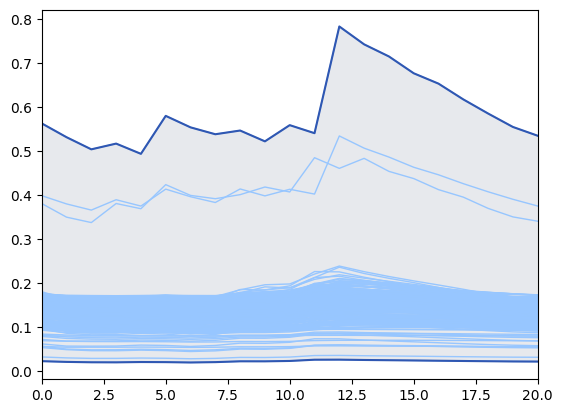

In [10]:
fig, ax = plt.subplots()

q_arr = []
for out in output_dicts_success:
    q_arr.append(out["Q_out"].values)

q_arr = np.array(q_arr)

for sim in range(q_arr.shape[0]):
    ax.plot(q_arr[sim, :], c="#97c6ff", lw=1., alpha=1.)

    # output_dicts_success[sim]["sks_seed"]

ax.fill_between(
    [i for i in range(q_arr.shape[1])],
    np.max(q_arr, axis=0),
    np.min(q_arr, axis=0),
    facecolor="#e7e9ed",
)

ax.plot(np.max(q_arr, axis=0), c="#2f57b2")
ax.plot(np.min(q_arr, axis=0), c="#2f57b2")

ax.set_xlim(0, q_arr.shape[1] - 1)